#### varaibles
- real gdp per capita growth - trend + cycle of real values? diff og gdp real per capita
- inflation = inflation trend + measurement errors???
- short rate = inflation trend + real rate trend 
- long rate = inflation trend + real rate trend + term trend
- inflation expectations??
- growth expextations??
- 

In [1]:
import Pkg
Pkg.activate("../")

using Revise

includet("../src/TCVAR/TCVAR.jl")

  Activating project at `~/projects/MacroFinanceScenarios`
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] (cache misses: wrong dep version loaded (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling Distributions [31c24e10-a181-5473-b8eb-7969acd0382f] (cache misses: wrong dep version loaded (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling SpecialFunctionsExt [997ecda8-951a-5f50-90ea-61382e97704b] (cache misses: wrong dep version loaded (4))

SYSTEM: caught exception of type :MethodError while trying to prin

In [2]:
using .TCVAR
using DataFrames, XLSX, TimeSeries
using StatsBase
using LinearAlgebra
using Plots


[ Info: Precompiling DataFrames [a93c6f00-e57d-5684-b7b6-d8193f3e46c0] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling ParsersExt [f526588d-e68b-5dc5-a62e-ff9f36e48b1a] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling BangBangDataFramesExt [d787bcad-b5c5-56bb-adaa-6bfddb178a59] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling XLSX [fdbf4ff8-1666-58a4-91e7-1b58723a45e0] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling StyledStringsSstsExt [35ed155e-ae73-5204-9ae1-dde3b2cd6668] (cache misses: wrong dep version loaded (2))



In [5]:
df = DataFrame(XLSX.readtable("../data/DelNegro.xlsx", "Sheet1"))
allowmissing!(df)

df[df.Date .>= Date(2008, 10, 1), :BILL] .= missing

data = TimeArray(df[!,[:Date, :Pi, :EPi, :BILL, :EBILL, :TBlong]]; timestamp = :Date)
presample, data = data[Date(1954,01,01):Date(1959,12,31)], data[Date(1960,01,01):Date(2016,12,31)]

display(presample)
display(data) 

24×5 TimeArray{Union{Missing, Float64}, 2, Date, Matrix{Union{Missing, Float64}}} 1954-01-01 to 1959-10-01
┌────────────┬──────────┬─────────┬──────┬─────────┬────────┐
│            │ Pi       │ EPi     │ BILL │ EBILL   │ TBlong │
├────────────┼──────────┼─────────┼──────┼─────────┼────────┤
│ 1954-01-01 │  2.01108 │ missing │ 1.06 │ missing │   2.71 │
│ 1954-04-01 │ -0.55724 │ missing │ 0.79 │ missing │   2.63 │
│ 1954-07-01 │ -1.31896 │ missing │ 0.88 │ missing │   2.58 │
│ 1954-10-01 │ -0.38172 │ missing │ 1.02 │ missing │   2.64 │
│ 1955-01-01 │   1.3246 │ missing │ 1.22 │ missing │   2.81 │
│ 1955-04-01 │  0.40624 │ missing │ 1.48 │ missing │   2.86 │
│ 1955-07-01 │  1.59788 │ missing │ 1.86 │ missing │   2.98 │
│ 1955-10-01 │  1.11152 │ missing │ 2.34 │ missing │   2.95 │
│ 1956-01-01 │  1.63748 │ missing │ 2.33 │ missing │   2.95 │
│ 1956-04-01 │  2.70964 │ missing │ 2.57 │ missing │   3.07 │
│ 1956-07-01 │  3.91252 │ missing │ 2.58 │ missing │   3.19 │
│     ⋮      │    ⋮     │

228×5 TimeArray{Union{Missing, Float64}, 2, Date, Matrix{Union{Missing, Float64}}} 1960-01-01 to 2016-10-01
┌────────────┬──────────┬────────┬─────────┬─────────┬────────┐
│            │ Pi       │ EPi    │ BILL    │ EBILL   │ TBlong │
├────────────┼──────────┼────────┼─────────┼─────────┼────────┤
│ 1960-01-01 │  0.52872 │ 1.6827 │    3.87 │ missing │   4.28 │
│ 1960-04-01 │  2.11204 │ 1.6827 │    2.99 │ missing │   4.16 │
│ 1960-07-01 │  1.53004 │ 1.6827 │    2.36 │ missing │   3.87 │
│ 1960-10-01 │  1.77444 │ 1.6827 │    2.31 │ missing │   3.93 │
│ 1961-01-01 │   0.7474 │ 1.6827 │    2.35 │ missing │   3.85 │
│ 1961-04-01 │  -0.0452 │ 1.6827 │     2.3 │ missing │   3.81 │
│ 1961-07-01 │   1.4696 │ 1.6827 │     2.3 │ missing │    4.0 │
│ 1961-10-01 │  0.45052 │ 1.6827 │    2.46 │ missing │   4.03 │
│ 1962-01-01 │  1.77756 │ 1.6827 │    2.72 │ missing │   4.09 │
│ 1962-04-01 │  1.38888 │ 1.6827 │    2.72 │ missing │   3.94 │
│ 1962-07-01 │  1.04924 │ 1.6827 │    2.84 │ missing │   4.0

In [6]:
n = 5 #number of observatin variables
nt = 3 #number of trends
p=4

# Minnesota prior for the cycle VAR (mean-zero cycle => white-noise prior, δ = 0).
# ψ is the prior scale of diag(Σc); with d = n+2 it equals the prior mean of diag(Σc).
cycle_prior = MinnesotaPrior(.2, n, p, [2., 1., 1., .5, 1.], n + 2; δ = zeros(n))

# prior mean of the cycle covariance, used for initial states / simulation below
cycle_covariance_mean = Matrix(cycle_prior.Ψ) / (cycle_prior.d - n - 1)

priors = (
        initial_trend_mean = [2., .5, 1.],
        initial_cycle_mean = zeros(n),
        initial_trend_covariance = diagm(fill(1,nt)),
        trend_covariance_df = 100,
        trend_covariance_mean = diagm([2., 1., 1.].^2 ./ 400),
        )


(initial_trend_mean = [2.0, 0.5, 1.0], initial_cycle_mean = [0.0, 0.0, 0.0, 0.0, 0.0], initial_trend_covariance = [1 0 0; 0 1 0; 0 0 1], trend_covariance_df = 100, trend_covariance_mean = [0.01 0.0 0.0; 0.0 0.0025 0.0; 0.0 0.0 0.0025])

In [7]:
observation_trend_mapping  = [1 0 0  
                              1 0 0  
                              1 1 0  
                              1 1 0  
                              1 1 1 ]



@time trend_states_samples, cycle_states_samples, trend_covariance_samples, betas_samples, sigmas_samples = TCVAR.gibbs_sampler(values(data), observation_trend_mapping, priors, cycle_prior; burnin = 1_000, n_samples = 1_000, thin=25, logging=true)

trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.68)  
cycle_states_mean, cycle_states_lower, cycle_states_upper = TCVAR.compute_posterior_statistics(cycle_states_samples, credible_level=0.95) 

Gibbs sampler: draw 2000 of 2000
484.571342 seconds (110.89 M allocations: 117.624 GiB, 20.84% gc time, 2.81% compilation time)


([-1.351167405291157 -0.7071502714148337 … -3.3139505167662167 -0.8403956521646005; -1.0558235091350148 -0.6944062570277423 … -3.254166546833848 -0.6967402175059604; … ; -0.3541984467095486 0.19084155244411188 … 0.32656770193465307 -1.5095559501504332; 0.3359744819311356 0.19389448366969902 … 0.7611651498903285 -0.8903937449051146], [-3.867704012646284 -1.6808539727361604 … -8.541729509258966 -3.2033123405511352; -3.8863047602655434 -1.7641398350763902 … -8.761971674026418 -2.7849420247771466; … ; -0.7361176164548583 -0.19107761802033954 … -2.006047612475075 -2.475281334064296; -0.015966559642208854 -0.1580465709683251 … -1.354241202669238 -1.888666763867168], [1.9017470088205024 0.097302143152161 … 0.5446743477732927 0.6706016128567035; 0.9279200246271545 0.27417627460367155 … 1.5602192079359976 0.8321327560210867; … ; 0.11201783128847631 0.6570578189048734 … 2.7008030260101834 -0.3993134960599136; 0.8237158234979389 0.6816358375141325 … 4.058124750482595 0.21460334115273558])

1 st version

Gibbs sampler: draw 2000 of 2000
484.571342 seconds (110.89 M allocations: 117.624 GiB, 20.84% gc time, 2.81% compilation time)

In [6]:
a = [1,2,3]'
b = ones(3,3)
vcat(a, b)

4×3 Matrix{Float64}:
 1.0  2.0  3.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0

In [7]:
p = zeros(5, 3, 2)
a = ones(3,2)

p[1,:,:] = a

p

5×3×2 Array{Float64, 3}:
[:, :, 1] =
 1.0  1.0  1.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0

[:, :, 2] =
 1.0  1.0  1.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0

In [8]:
show(err)


nothing

In [9]:
priors.initial_trend_covariance

3×3 Matrix{Int64}:
 1  0  0
 0  1  0
 0  0  1

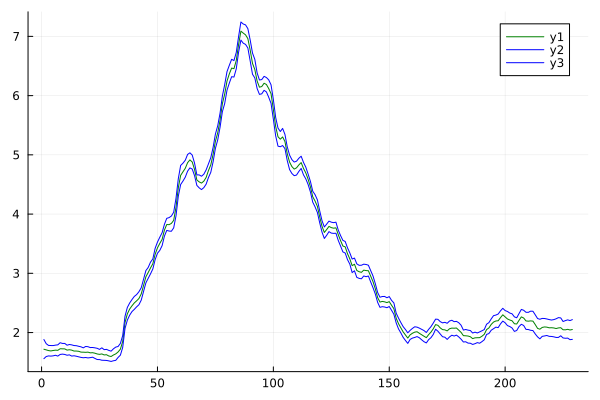

In [10]:
st = 1
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

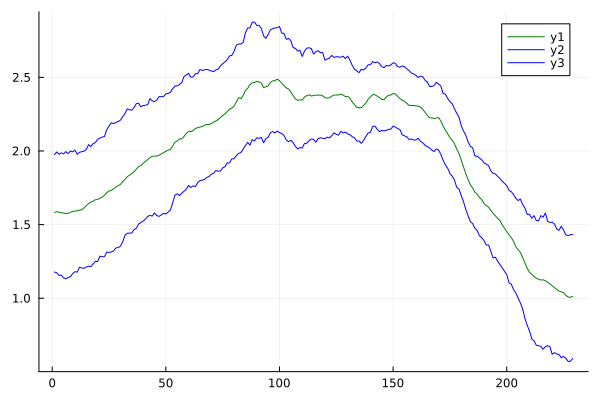

In [11]:
st = 2
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

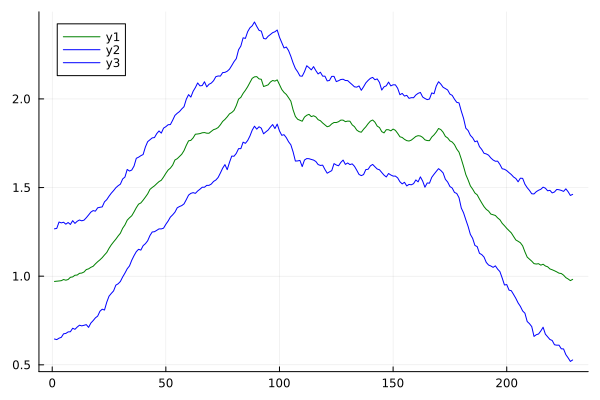

In [12]:
st = 3
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

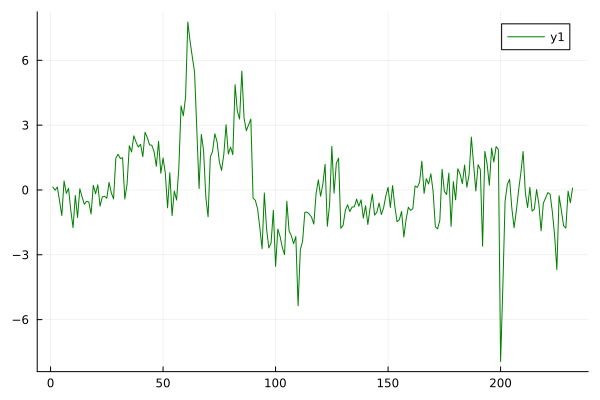

In [13]:
st=1
plot(cycle_states_mean[:,st], color="green" )

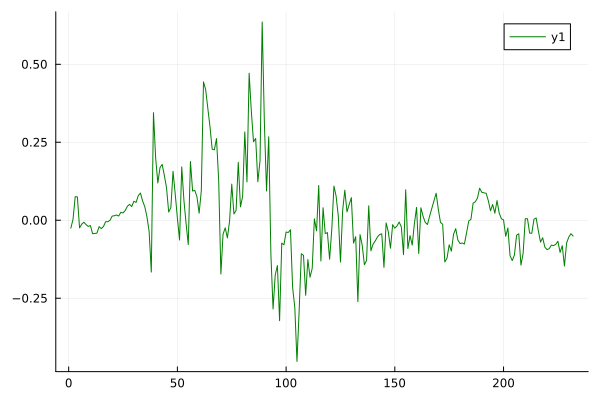

In [14]:
st=2
plot(cycle_states_mean[:,st], color="green" )

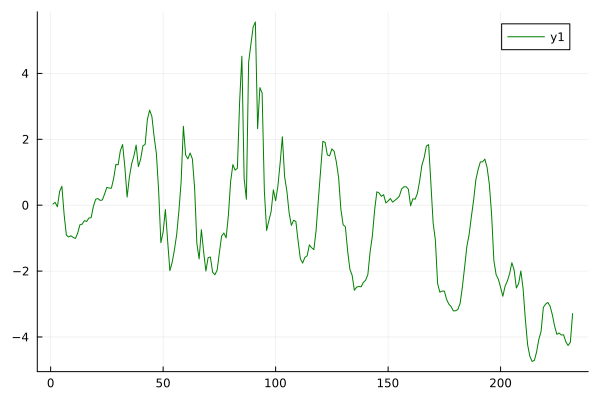

In [15]:
st=3
plot(cycle_states_mean[:,st], color="green" )

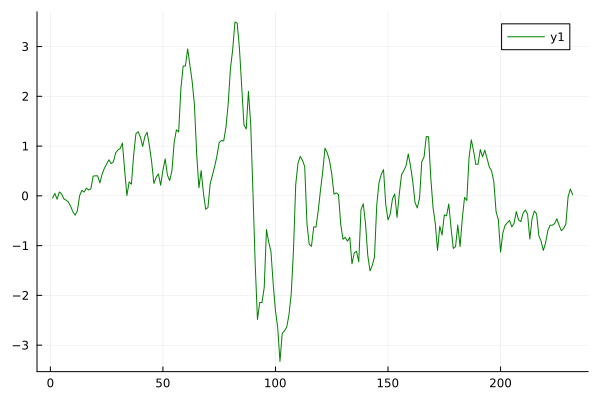

In [16]:
st=4
plot(cycle_states_mean[:,st], color="green" )

In [17]:
summarystats(trend_covariance_samples)

Summary Statistics

  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

         Στ1    0.0151    0.0017    0.0001   236.8913   292.6484    1.0025     ⋯
         Στ2    0.0006    0.0008    0.0001   138.1580   153.7754    1.0198     ⋯
         Στ3    0.0008    0.0008    0.0001   133.2055   221.6820    1.0157     ⋯
         Στ4    0.0006    0.0008    0.0001   138.1580   153.7754    1.0198     ⋯
         Στ5    0.0031    0.0005    0.0001    38.6536   253.9560    1.0444     ⋯
         Στ6    0.0002    0.0003    0.0000    86.0457   182.3852    1.0088     ⋯
         Στ7    0.0008    0.0008    0.0001   133.2055   221.6820    1.0157     ⋯
         Στ8    0.0002    0.0003    0.0000    86.0457   182.3852    1.0088     ⋯
         Στ9    0.0030    0.0005    0.0000   130.6448   253.7746    1.0162     ⋯

                                                                1 column omitted


In [18]:
summarystats(betas_samples)

Summary Statistics

  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

          β1   -0.0034    0.0384    0.0028   183.4303   174.2717    1.0111     ⋯
          β2    0.0094    0.0622    0.0040   243.9703   237.8323    1.0141     ⋯
          β3   -0.0112    0.0525    0.0038   179.2780   282.4423    0.9995     ⋯
          β4    0.0358    0.0805    0.0058   188.6629   232.6713    1.0006     ⋯
          β5   -0.0158    0.0638    0.0042   233.4578   336.5234    0.9998     ⋯
          β6    0.0767    0.0483    0.0033   216.0033   334.3508    1.0123     ⋯
          β7    0.0059    0.0864    0.0048   330.6332   290.2689    1.0000     ⋯
          β8   -0.0182    0.0694    0.0043   264.5177   215.4000    1.0035     ⋯
          β9    0.0473    0.1081    0.0078   192.8582   179.6078    0.9979     ⋯
         β10   -0.0348    0.0778    0.0048   276.3474   227.9918    1.0034     ⋯
       

In [19]:
summarystats(sigmas_samples)

Summary Statistics

  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

         Σc1    1.6264    0.1573    0.0107   225.2027   253.9560    0.9978     ⋯
         Σc2    0.0072    0.0179    0.0015   152.4858   255.9498    1.0055     ⋯
         Σc3    0.1275    0.0838    0.0068   158.0148   258.2324    0.9969     ⋯
         Σc4    0.2069    0.1133    0.0168    45.4078   166.2518    0.9994     ⋯
         Σc5    0.1102    0.0412    0.0035   141.2427   293.7070    1.0160     ⋯
         Σc6    0.0072    0.0179    0.0015   152.4858   255.9498    1.0055     ⋯
         Σc7    0.0169    0.0022    0.0001   216.9629   242.9901    0.9971     ⋯
         Σc8    0.0061    0.0125    0.0015    73.5618   183.6657    1.0132     ⋯
         Σc9   -0.0012    0.0127    0.0023    29.5980    83.1385    1.0713     ⋯
        Σc10    0.0023    0.0063    0.0006   105.1543   168.2869    1.0040     ⋯
       

In [20]:
plot(betas_samples)

┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.

LoadError: The backend must not support the series type Val{:density}, and there isn't a series recipe defined.

In [ ]:
Σc = mean(sigmas_samples).nt.mean
Σc = reshape(Σc, n, n)
display(Σc)

β = mean(betas_samples).nt.mean
β = reshape(β, n, n*1)
display(β)

Στ = mean(trend_covariance_samples).nt.mean
Στ = reshape(Στ, nt, nt)
display(cov2cor(Στ))
display(diag(Στ) .^ .5)

5×5 Matrix{Float64}:
 1.79411      0.0424067     0.107201      0.00168398  0.120538
 0.0424067    0.280499     -0.000688154  -0.00238186  0.0390318
 0.107201    -0.000688154   0.709402      0.025241    0.100141
 0.00168398  -0.00238186    0.025241      0.853156    0.00845605
 0.120538     0.0390318     0.100141      0.00845605  0.475342

5×5 Matrix{Float64}:
  0.401899    -0.00832014   0.0429888  -0.0062348   -0.0359921
 -0.110923     0.712294     0.104339   -0.00848358   0.131948
  0.111276     0.00664144   0.825852    0.0432068    0.0519225
  0.00460987  -0.00433078   0.0367354   0.0277545    0.00855234
 -0.260648     0.0942786   -0.0249877   0.0138357    0.768959

3×3 Matrix{Float64}:
 1.0       0.151828  0.142649
 0.151828  1.0       0.120919
 0.142649  0.120919  1.0

3-element Vector{Float64}:
 0.15282605806088212
 0.057652243368346144
 0.0548315413071181

In [ ]:
display(diag(Σc) .^ .5)

display(diag(Στ) .^ .5)

5-element Vector{Float64}:
 1.3394439805855263
 0.5296218035391672
 0.8422602583460558
 0.9236646804189055
 0.6894508021175776

3-element Vector{Float64}:
 0.15282605806088212
 0.057652243368346144
 0.0548315413071181

In [ ]:
model = tc_var(observation_tend_mapping, β, Στ, Σc, priors.initial_trend_mean, priors.initial_cycle_mean, priors.initial_trend_covariance, cycle_covariance_mean)

initial_states = [trend_states_mean[end,:]; cycle_states_mean[end,:]]

n_samples = 2_000
T = 100
states = zeros(n_samples, T, 8)

observations = zeros(n_samples, T, n)

for s in 1:2_000
    states[s, :, :], observations[s, :, :] = sample(model, initial_states, T)
end


UndefVarError: UndefVarError: `observation_tend_mapping` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
transformed_scenarios = permutedims(observations, (3, 2, 1))[[1,2],:,:] ./400
periods = [1, 5, 10, 25]
freq = 4
assets_names = ["GDP", "CPI"]
ret_in_years = cum_returns_in_periods(transformed_scenarios, periods, freq, true)
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:2
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end  

UndefVarError: UndefVarError: `observations` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
transformed_scenarios = permutedims(observations[:,:,[3,4]] , (3, 2, 1))
freq = 4

transformed_scenarios = transformed_scenarios[:,freq:freq:end,:]

periods = [1, 5, 10, 25]


assets_names = ["ShortRate", "LongRate"]
ret_in_years = transformed_scenarios = transformed_scenarios[:,periods,:]
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:2
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end  

UndefVarError: UndefVarError: `observations` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
n_observations = size(model.T,1)
n_trends = 4
n_time_steps = size(data,1)
n_draws = 1000
trends_states = zeros(n_draws, n_time_steps, n_trends)

for s in 1:n_draws
    state_smoothed_samples = carter_kohn_sampler(model, values(data))
    trends_states[s,:,:] = state_smoothed_samples[:, 1:n_trends]
end

trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.95) 

UndefVarError: UndefVarError: `model` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
st = 2
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

UndefVarError: UndefVarError: `trend_states_mean` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
st = 3
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

UndefVarError: UndefVarError: `trend_states_mean` not defined in `Main`
Suggestion: check for spelling errors or missing imports.